# Notebook pilote — Iran strikes cluster (28 fév 2026)

**Objectif** : valider la stack technique (Dune API + CLOB/Gamma APIs + DuckDB + polars) en reconstituant le cluster Bubblemaps de 7 wallets sur le marché "US strikes Iran by February 28, 2026?" (~$90M volume, résolu YES).

**Ground truth** : 6 wallets cluster Bubblemaps + Magamyman. Tous fresh wallets (joined 17-27 fév 2026), concentration ~100% sur ce marché, profit combiné ~$1.56M.

**Decision gate** : si on retrouve ≥ 5/7 wallets avec les features Niveau A (fresh + concentré + pré-event), la stack est validée pour la phase D.

---

## Partie 1 — Setup et chargement ground truth

### 1.1 Imports et configuration

On utilise polars (pas pandas) pour la perf, DuckDB pour le SQL analytique local, et httpx pour les appels API avec contrôle fin des timeouts et retries. Les clés API sont chargées depuis `.env` via python-dotenv.

In [1]:
import os
import json
import time
from pathlib import Path
from datetime import datetime, timezone

import polars as pl
import duckdb
import httpx
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from dotenv import load_dotenv

# Chemins projet
ROOT = Path("..").resolve()
GT_DIR = ROOT / "data" / "ground_truth"
RAW_DIR = ROOT / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

# Charger .env (DUNE_API_KEY requis pour Partie 2)
load_dotenv(ROOT / ".env")
DUNE_API_KEY = os.getenv("DUNE_API_KEY", "")
if not DUNE_API_KEY:
    print("⚠ DUNE_API_KEY manquante — Partie 2 (Dune) sera skippée, fallback CLOB API")
else:
    print(f"✓ DUNE_API_KEY chargée ({DUNE_API_KEY[:8]}...)")

# Style plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 5)

print(f"✓ Setup OK — polars {pl.__version__}, duckdb {duckdb.__version__}")

✓ DUNE_API_KEY chargée (Qf8pexuk...)
✓ Setup OK — polars 1.40.0, duckdb 1.5.2


### 1.2 Constantes du marché Iran strikes

Identifiants techniques récupérés via l'API Gamma. Le marché est sur le **vanilla CTF Exchange** (negRisk=false), ce qui simplifie les queries — une seule table Dune à interroger.

In [2]:
# --- Identifiants du marché Iran strikes ---
MARKET = {
    "id": "1198423",
    "question": "US strikes Iran by February 28, 2026?",
    "condition_id": "0x3488f31e6449f9803f99a8b5dd232c7ad883637f1c86e6953305a2ef19c77f20",
    "token_yes": "110790003121442365126855864076707686014650523258783405996925622264696084778807",
    "token_no": "10832696757358093775468120009000761778513405247768868107262967513475277652998",
    "neg_risk": False,
    "resolution": "Yes",
    "event_date": datetime(2026, 2, 28, 9, 31, tzinfo=timezone.utc),
    "volume_usd": 89_652_867,
}

# Période de backfill : 30 jours avant l'event pour capturer le buildup
BACKFILL_START = datetime(2026, 1, 29, tzinfo=timezone.utc)
BACKFILL_END = datetime(2026, 3, 1, tzinfo=timezone.utc)

print(f"Marché : {MARKET['question']}")
print(f"Condition ID : {MARKET['condition_id']}")
print(f"Résolu : {MARKET['resolution']} le {MARKET['event_date'].strftime('%Y-%m-%d %H:%M UTC')}")
print(f"Volume : ${MARKET['volume_usd']:,.0f}")
print(f"Backfill : {BACKFILL_START.date()} → {BACKFILL_END.date()}")
print(f"Exchange : {'Neg Risk' if MARKET['neg_risk'] else 'Vanilla CTF'}")

Marché : US strikes Iran by February 28, 2026?
Condition ID : 0x3488f31e6449f9803f99a8b5dd232c7ad883637f1c86e6953305a2ef19c77f20
Résolu : Yes le 2026-02-28 09:31 UTC
Volume : $89,652,867
Backfill : 2026-01-29 → 2026-03-01
Exchange : Vanilla CTF


### 1.3 Chargement du ground truth

On charge les 3 CSVs existants et on filtre sur le cas Iran (case_id=2). Les wallets attendus sont les 6 du cluster Bubblemaps + Magamyman.

In [3]:
# Charger les CSVs ground truth
cases = pl.read_csv(GT_DIR / "cases.csv", truncate_ragged_lines=True)
wallets = pl.read_csv(GT_DIR / "wallets.csv", truncate_ragged_lines=True)
sharps = pl.read_csv(GT_DIR / "sharps_positive.csv", truncate_ragged_lines=True)

# Filtrer sur le cas Iran strikes (case_id = 2)
iran_cases = cases.filter(pl.col("case_id") == 2)
iran_wallets = wallets.filter(pl.col("case_id") == 2)

# Extraire les adresses connues (non vides)
gt_addresses = (
    iran_wallets
    .filter(pl.col("address").is_not_null() & (pl.col("address") != ""))
    .select("address", "cluster_name", "role", "notes")
)

print(f"=== Ground Truth Iran strikes (case_id=2) ===")
print(f"Lignes dans wallets.csv : {len(iran_wallets)}")
print(f"Adresses connues       : {len(gt_addresses)}")
print(f"Adresses manquantes    : {len(iran_wallets) - len(gt_addresses)}")
print()

# Liste des adresses à chercher dans les trades (lowercase pour matching)
GT_ADDRS = [a.lower() for a in gt_addresses["address"].to_list()]

print("Adresses cibles (lowercase) :")
for i, row in enumerate(gt_addresses.iter_rows(named=True)):
    addr = row["address"]
    note = row["notes"][:60] if row["notes"] else ""
    print(f"  {i+1}. {addr[:10]}...{addr[-6:]}  — {note}")

=== Ground Truth Iran strikes (case_id=2) ===
Lignes dans wallets.csv : 8
Adresses connues       : 7
Adresses manquantes    : 1

Adresses cibles (lowercase) :
  1. 0x1caA6a7a...4846a0  — 560 680 Yes shares @ ~$0.108. Profit ~$494 375. Plus gros ga
  2. 0xa4eb5222...acd010  — nothingeverhappens911. Lié à cluster Skoobidoobnj via dépôt 
  3. 0x3811e09b...478f61  — 
  4. 0xdde15ebd...2e02c5  — @Dicedicedice. 150 000 shares @ $0.20. Profit ~$120 000. Joi
  5. 0x56efadc9...4136db  — @Neodbs. $89K profit. 1 prediction. Joined Feb 26 2026. Enri
  6. 0x38745db2...149801  — @Planktonbets. $174K profit. 7 predictions. Joined Feb 17 20
  7. 0x4dfd481c...9f6e4a  — Magamyman. Actif depuis oct 2024. +$814K P&L (API). Premier 


---

## Partie 2 — Ingestion des trades

**Pivot** : l'endpoint CLOB `/trades` est désormais auth-only (401 sans clé API). On utilise la **Data API** (`data-api.polymarket.com/trades?user=<addr>`) qui reste publique et ne nécessite aucune authentification.

**Approche** : au lieu de pull tous les trades du marché puis filtrer, on query wallet par wallet (les 7 adresses ground truth), puis on filtre côté client sur le `conditionId` du marché Iran. C'est plus ciblé et suffisant pour le pilote.

Le marché est sur le vanilla CTF Exchange (negRisk=false). La Data API retourne directement `conditionId`, `side`, `size`, `price`, `timestamp`, `outcome` — pas besoin de mapper manuellement.

### 2.1 Helper — appels API avec retry et rate limiting

Fonction utilitaire pour tous les appels HTTP avec backoff exponentiel sur les 429 et logging du nombre d'appels.

In [4]:
class APIStats:
    """Compteur global d'appels API pour le logging en fin de partie."""
    def __init__(self):
        self.calls = 0
        self.errors = 0
        self.retries = 0

    def summary(self, label: str) -> str:
        return f"[{label}] {self.calls} calls, {self.retries} retries, {self.errors} errors"

stats_clob = APIStats()
stats_gamma = APIStats()
stats_dune = APIStats()


def api_get(url: str, params: dict = None, stats: APIStats = None,
            sleep_s: float = 0.12, max_retries: int = 3, timeout: float = 30.0) -> dict | list | None:
    """GET request with retry + backoff on 429. Returns parsed JSON or None on failure."""
    if stats:
        stats.calls += 1
    for attempt in range(max_retries):
        try:
            time.sleep(sleep_s)
            with httpx.Client(timeout=timeout) as client:
                resp = client.get(url, params=params)
            if resp.status_code == 200:
                return resp.json()
            elif resp.status_code == 429:
                wait = 2 ** (attempt + 1)
                print(f"  429 rate-limited, retrying in {wait}s...")
                if stats:
                    stats.retries += 1
                time.sleep(wait)
            else:
                print(f"  HTTP {resp.status_code} on {url}")
                if stats:
                    stats.errors += 1
                return None
        except httpx.TimeoutException:
            print(f"  Timeout on {url}, attempt {attempt+1}/{max_retries}")
            if stats:
                stats.retries += 1
            time.sleep(2 ** attempt)
        except Exception as e:
            print(f"  Error: {e}")
            if stats:
                stats.errors += 1
            return None
    print(f"  Failed after {max_retries} retries: {url}")
    if stats:
        stats.errors += 1
    return None

print("✓ Helper API prêt")

✓ Helper API prêt


### 2.2 Ingestion via Data API (wallet par wallet)

L'endpoint `GET /trades?user=<address>` retourne tous les trades d'un wallet, paginés. On itère sur chaque adresse ground truth, puis on filtre côté client sur le `conditionId` du marché Iran. Rate limit : sleep 1s entre wallets pour rester safe.

In [5]:
DATA_API = "https://data-api.polymarket.com"
IRAN_CONDITION_ID = MARKET["condition_id"]

stats_data = APIStats()


def fetch_wallet_trades(address: str, limit: int = 500) -> list[dict]:
    """Fetch all trades for a wallet via Data API, with pagination via offset."""
    all_trades = []
    offset = 0

    while True:
        data = api_get(
            f"{DATA_API}/trades",
            params={"user": address, "limit": limit, "offset": offset},
            stats=stats_data, sleep_s=1.0, timeout=30.0
        )
        if data is None:
            print(f"    ✗ Erreur sur offset={offset}, arrêt pour ce wallet")
            break

        trades = data if isinstance(data, list) else data.get("data", [])
        if not trades:
            break

        all_trades.extend(trades)
        offset += len(trades)

        # Si on a reçu moins que limit, c'est la dernière page
        if len(trades) < limit:
            break

    return all_trades


# --- Ingestion wallet par wallet ---
print(f"Ingestion via Data API — {len(GT_ADDRS)} wallets ground truth")
print(f"Filtre conditionId : {IRAN_CONDITION_ID}")
print()

all_iran_trades = []

for addr in GT_ADDRS:
    short = addr[:8] + "..." + addr[-4:]
    print(f"  {short} : ", end="")

    wallet_trades = fetch_wallet_trades(addr)
    print(f"{len(wallet_trades)} trades totaux", end="")

    # Filtrer sur le marché Iran (conditionId match)
    iran_trades = [t for t in wallet_trades if t.get("conditionId") == IRAN_CONDITION_ID]
    print(f" → {len(iran_trades)} sur marché Iran")

    # Ajouter l'adresse wallet dans chaque trade pour le tracking
    for t in iran_trades:
        t["wallet"] = addr.lower()

    all_iran_trades.extend(iran_trades)

print(f"\n{'='*50}")
print(f"Total trades Iran cluster : {len(all_iran_trades)}")
print(stats_data.summary("Data API"))

Ingestion via Data API — 7 wallets ground truth
Filtre conditionId : 0x3488f31e6449f9803f99a8b5dd232c7ad883637f1c86e6953305a2ef19c77f20

  0x1caa6a...46a0 : 43 trades totaux → 8 sur marché Iran
  0xa4eb52...d010 : 22 trades totaux → 1 sur marché Iran
  0x3811e0...8f61 : 12 trades totaux → 1 sur marché Iran
  0xdde15e...02c5 : 4 trades totaux → 1 sur marché Iran
  0x56efad...36db : 1 trades totaux → 1 sur marché Iran
  0x38745d...9801 : 18 trades totaux → 5 sur marché Iran
  0x4dfd48...6e4a : 334 trades totaux → 36 sur marché Iran

Total trades Iran cluster : 53
[Data API] 7 calls, 0 retries, 0 errors


### 2.3 Normalisation et stockage en Parquet

La Data API retourne des colonnes standardisées : `proxyWallet`, `side`, `size`, `price`, `timestamp` (epoch seconds), `conditionId`, `outcome`, `transactionHash`, `title`, `name`. On normalise les types et on stocke en Parquet.

In [6]:
if all_iran_trades:
    # Inspecter le schéma
    sample = all_iran_trades[0]
    print("Clés disponibles dans un trade Data API :")
    for k, v in sample.items():
        print(f"  {k}: {type(v).__name__} = {str(v)[:80]}")
else:
    print("⚠ Aucun trade récupéré — vérifier les adresses et le conditionId")

Clés disponibles dans un trade Data API :
  proxyWallet: str = 0x1caa6a7ad0c6916aef7b67946de2e57ad24846a0
  side: str = BUY
  asset: str = 110790003121442365126855864076707686014650523258783405996925622264696084778807
  conditionId: str = 0x3488f31e6449f9803f99a8b5dd232c7ad883637f1c86e6953305a2ef19c77f20
  size: float = 343.31
  price: float = 0.17
  timestamp: int = 1772226211
  title: str = US strikes Iran by February 28, 2026?
  slug: str = us-strikes-iran-by-february-28-2026-227-967-547-688-589-491-592-418-452-924-384-
  icon: str = https://polymarket-upload.s3.us-east-2.amazonaws.com/us-strikes-iran-by-october-
  eventSlug: str = us-strikes-iran-by
  outcome: str = Yes
  outcomeIndex: int = 0
  name: str = 0x1caA6a7ad0c6916aeF7b67946De2e57Ad24846a0-1772054568088
  pseudonym: str = Careless-Bug
  bio: str = 
  profileImage: str = 
  profileImageOptimized: str = 
  transactionHash: str = 0xdff7ed9891b0a1146d9668508b2e59ec788467dce129d35fa0b5b90f31a853fc
  wallet: str = 0x1caa6a7ad0c

In [7]:
if all_iran_trades:
    df = pl.DataFrame(all_iran_trades)

    # Sélectionner et renommer les colonnes utiles
    keep_cols = {
        "wallet": "wallet",
        "proxyWallet": "proxy_wallet",
        "side": "side",
        "size": "size",
        "price": "price",
        "timestamp": "timestamp",
        "outcome": "outcome",
        "outcomeIndex": "outcome_index",
        "conditionId": "condition_id",
        "transactionHash": "tx_hash",
        "title": "title",
        "name": "username",
        "asset": "asset_id",
    }
    # Garder seulement les colonnes présentes
    rename_map = {k: v for k, v in keep_cols.items() if k in df.columns}
    df = df.select(list(rename_map.keys())).rename(rename_map)

    # Cast types
    df = df.with_columns([
        pl.col("size").cast(pl.Float64),
        pl.col("price").cast(pl.Float64),
        pl.col("wallet").str.to_lowercase(),
    ])

    # Convertir timestamp epoch → datetime
    if df["timestamp"].dtype in (pl.Int64, pl.Float64):
        df = df.with_columns(
            pl.from_epoch(pl.col("timestamp"), time_unit="s").alias("datetime")
        )
    elif df["timestamp"].dtype == pl.String:
        df = df.with_columns(
            pl.from_epoch(pl.col("timestamp").cast(pl.Int64), time_unit="s").alias("datetime")
        )

    # Calculer size en USDC (size = nb shares, USDC = size * price)
    df = df.with_columns(
        (pl.col("size") * pl.col("price")).alias("size_usd")
    )

    # Trier par timestamp
    df = df.sort("datetime")

    # Sauvegarder
    parquet_path = RAW_DIR / "iran_trades.parquet"
    df.write_parquet(parquet_path)

    print(f"✓ {len(df)} trades normalisés")
    print(f"  Colonnes : {df.columns}")
    print(f"  Période  : {df['datetime'].min()} → {df['datetime'].max()}")
    print(f"  Sauvegardé : {parquet_path} ({parquet_path.stat().st_size / 1024:.0f} KB)")
    print()
    print(df.head(5))
else:
    df = pl.DataFrame()
    print("⚠ DataFrame vide — pas de trades Iran trouvés")

✓ 53 trades normalisés
  Colonnes : ['wallet', 'proxy_wallet', 'side', 'size', 'price', 'timestamp', 'outcome', 'outcome_index', 'condition_id', 'tx_hash', 'title', 'username', 'asset_id', 'datetime', 'size_usd']
  Période  : 2026-01-20 20:43:40 → 2026-02-28 06:35:49
  Sauvegardé : /Users/gabsav/Documents/Polycasquette/Code/data/raw/iran_trades.parquet (12 KB)

shape: (5, 15)
┌────────────┬────────────┬──────┬───────────┬───┬───────────┬────────────┬────────────┬───────────┐
│ wallet     ┆ proxy_wall ┆ side ┆ size      ┆ … ┆ username  ┆ asset_id   ┆ datetime   ┆ size_usd  │
│ ---        ┆ et         ┆ ---  ┆ ---       ┆   ┆ ---       ┆ ---        ┆ ---        ┆ ---       │
│ str        ┆ ---        ┆ str  ┆ f64       ┆   ┆ str       ┆ str        ┆ datetime[μ ┆ f64       │
│            ┆ str        ┆      ┆           ┆   ┆           ┆            ┆ s]         ┆           │
╞════════════╪════════════╪══════╪═══════════╪═══╪═══════════╪════════════╪════════════╪═══════════╡
│ 0x4dfd481c ┆ 

### 2.4 Checkpoint Partie 2

Vérification rapide : combien de trades récupérés, volume total, et les adresses ground truth sont-elles présentes ?

In [8]:
# Checkpoint Partie 2
if len(df) > 0:
    # Volume total
    total_vol = df["size_usd"].sum() if "size_usd" in df.columns else df["size"].sum()
    total_shares = df["size"].sum()
    print(f"Volume total      : {total_shares:,.0f} shares (~${total_vol:,.0f} USDC)")
    print(f"Trades uniques    : {len(df)}")

    # Wallets présents
    wallets_in_data = df["wallet"].unique().to_list()
    print(f"\nWallets dans les données : {len(wallets_in_data)}")

    found = 0
    for addr in GT_ADDRS:
        present = addr in wallets_in_data
        if present:
            found += 1
            n = len(df.filter(pl.col("wallet") == addr))
            vol = df.filter(pl.col("wallet") == addr)["size_usd"].sum()
            status = f"✓ TROUVÉ — {n} trades, ~${vol:,.0f}"
        else:
            status = "✗ ABSENT"
        print(f"  {addr[:10]}...{addr[-4:]} : {status}")

    print(f"\n{'='*50}")
    print(f"CHECKPOINT 2 : {found}/{len(GT_ADDRS)} wallets ground truth retrouvés")
    print(f"{'='*50}")
else:
    print("⚠ Pas de données — vérifier Partie 2.2")

Volume total      : 3,011,021 shares (~$854,456 USDC)
Trades uniques    : 53

Wallets dans les données : 7
  0x1caa6a7a...46a0 : ✓ TROUVÉ — 8 trades, ~$53,286
  0xa4eb5222...d010 : ✓ TROUVÉ — 1 trades, ~$4,087
  0x3811e09b...8f61 : ✓ TROUVÉ — 1 trades, ~$10,000
  0xdde15ebd...02c5 : ✓ TROUVÉ — 1 trades, ~$11,272
  0x56efadc9...36db : ✓ TROUVÉ — 1 trades, ~$9,884
  0x38745db2...9801 : ✓ TROUVÉ — 5 trades, ~$26,514
  0x4dfd481c...6e4a : ✓ TROUVÉ — 36 trades, ~$739,414

CHECKPOINT 2 : 7/7 wallets ground truth retrouvés


---

## Partie 3 — Enrichissement métadonnées

On complète les trades avec trois sources :
1. **Gamma API** — metadata marché (question exacte, outcomes, résolution, dates)
2. **Data API** — profils et historiques des wallets cibles
3. **CLOB API** — prix OHLC historiques pour tracer la timeline du marché

### 3.1 Metadata marché via Gamma API

On récupère les détails complets du marché pour vérifier la cohérence avec nos constantes (question, resolution status, dates).

In [9]:
# Gamma API — metadata du marché
market_meta = api_get(
    f"https://gamma-api.polymarket.com/markets/{MARKET['id']}",
    stats=stats_gamma, sleep_s=0.5
)

if market_meta:
    # Sauvegarder le JSON complet
    meta_path = RAW_DIR / "iran_metadata.json"
    with open(meta_path, "w") as f:
        json.dump(market_meta, f, indent=2)

    print("=== Metadata marché (Gamma API) ===")
    for key in ["question", "conditionId", "outcomes", "outcomePrices",
                "volume", "closed", "umaResolutionStatus", "negRisk",
                "startDate", "endDate", "closedTime"]:
        val = market_meta.get(key, "N/A")
        print(f"  {key}: {val}")

    print(f"\n✓ Sauvegardé : {meta_path}")
else:
    print("✗ Impossible de récupérer les metadata Gamma")

=== Metadata marché (Gamma API) ===
  question: US strikes Iran by February 28, 2026?
  conditionId: 0x3488f31e6449f9803f99a8b5dd232c7ad883637f1c86e6953305a2ef19c77f20
  outcomes: ["Yes", "No"]
  outcomePrices: ["1", "0"]
  volume: 89652867.363489
  closed: True
  umaResolutionStatus: resolved
  negRisk: False
  startDate: 2026-01-19T20:34:32.385Z
  endDate: 2026-01-31T00:00:00Z
  closedTime: 2026-02-28 09:31:17+00

✓ Sauvegardé : /Users/gabsav/Documents/Polycasquette/Code/data/raw/iran_metadata.json


### 3.2 Prix historiques via Gamma API

L'endpoint CLOB `/prices-history` a renvoyé vide sur ce marché résolu. On utilise les prix d'entrée de nos trades (colonne `price`) pour reconstituer la timeline de prix. En complément, l'endpoint Gamma `/markets/{id}` contient `outcomePrices` (prix final) qu'on a déjà récupéré en 3.1.

In [10]:
# Reconstituer une timeline de prix à partir des trades (prix d'entrée par heure)
if len(df) > 0 and "datetime" in df.columns and "price" in df.columns:
    df_prices = (
        df
        .with_columns(pl.col("datetime").dt.truncate("1h").alias("hour"))
        .group_by("hour")
        .agg([
            pl.col("price").mean().alias("price_mean"),
            pl.col("price").min().alias("price_min"),
            pl.col("price").max().alias("price_max"),
            pl.col("size_usd").sum().alias("volume_usd"),
            pl.len().alias("n_trades"),
        ])
        .sort("hour")
    )

    prices_path = RAW_DIR / "iran_prices.parquet"
    df_prices.write_parquet(prices_path)

    print(f"✓ Timeline prix reconstituée : {len(df_prices)} points horaires")
    print(f"  Période : {df_prices['hour'].min()} → {df_prices['hour'].max()}")
    print(f"  Sauvegardé : {prices_path}")
    print()
    print(df_prices.tail(10))
else:
    df_prices = pl.DataFrame()
    print("⚠ Pas de données pour reconstituer les prix")

✓ Timeline prix reconstituée : 24 points horaires
  Période : 2026-01-20 20:00:00 → 2026-02-28 06:00:00
  Sauvegardé : /Users/gabsav/Documents/Polycasquette/Code/data/raw/iran_prices.parquet

shape: (10, 6)
┌─────────────────────┬────────────┬───────────┬───────────┬──────────────┬──────────┐
│ hour                ┆ price_mean ┆ price_min ┆ price_max ┆ volume_usd   ┆ n_trades │
│ ---                 ┆ ---        ┆ ---       ┆ ---       ┆ ---          ┆ ---      │
│ datetime[μs]        ┆ f64        ┆ f64       ┆ f64       ┆ f64          ┆ u32      │
╞═════════════════════╪════════════╪═══════════╪═══════════╪══════════════╪══════════╡
│ 2026-02-27 15:00:00 ┆ 0.815016   ┆ 0.810033  ┆ 0.82      ┆ 49165.0498   ┆ 2        │
│ 2026-02-27 17:00:00 ┆ 0.51       ┆ 0.19      ┆ 0.83      ┆ 32505.974699 ┆ 2        │
│ 2026-02-27 18:00:00 ┆ 0.148144   ┆ 0.137884  ┆ 0.1563    ┆ 56495.4736   ┆ 3        │
│ 2026-02-27 19:00:00 ┆ 0.15       ┆ 0.15      ┆ 0.15      ┆ 3999.999999  ┆ 2        │
│ 2026-02-

### 3.3 Log API Partie 3

In [11]:
print("=== Log API cumulé ===")
print(stats_clob.summary("CLOB"))
print(stats_gamma.summary("Gamma"))
print(stats_data.summary("Data API"))
print(stats_dune.summary("Dune"))

# Fichiers produits
print("\n=== Fichiers produits ===")
for p in sorted(RAW_DIR.glob("iran_*")):
    print(f"  {p.name} ({p.stat().st_size / 1024:.0f} KB)")

=== Log API cumulé ===
[CLOB] 0 calls, 0 retries, 0 errors
[Gamma] 1 calls, 0 retries, 0 errors
[Data API] 7 calls, 0 retries, 0 errors
[Dune] 0 calls, 0 retries, 0 errors

=== Fichiers produits ===
  iran_metadata.json (4 KB)
  iran_prices.parquet (3 KB)
  iran_timeline.png (106 KB)
  iran_trades.parquet (12 KB)


---

## Partie 4 — Validation et analyse

On vérifie que les wallets ground truth sont bien dans les données, on calcule leurs métriques clés (volume, timing, concentration), et on produit la visualisation timeline.

### 4.1 Table de vérification par wallet

Pour chaque wallet ground truth, on extrait : nombre de trades, volume cumulé, premier et dernier trade, et on compare avec les dates attendues (joined 17-27 fév 2026).

In [12]:
# Charger les données depuis le Parquet (point de reprise si on relance)
parquet_path = RAW_DIR / "iran_trades.parquet"
if parquet_path.exists():
    df = pl.read_parquet(parquet_path)
    print(f"Trades chargés : {len(df)}")
    print(f"Colonnes : {df.columns}")
else:
    print("⚠ iran_trades.parquet n'existe pas — relancer la Partie 2")
    df = pl.DataFrame()

Trades chargés : 53
Colonnes : ['wallet', 'proxy_wallet', 'side', 'size', 'price', 'timestamp', 'outcome', 'outcome_index', 'condition_id', 'tx_hash', 'title', 'username', 'asset_id', 'datetime', 'size_usd']


In [13]:
# Table de vérification : chaque wallet ground truth vs données
event_dt = MARKET["event_date"]
results = []

for addr in GT_ADDRS:
    wallet_trades = df.filter(pl.col("wallet") == addr) if len(df) > 0 else pl.DataFrame()
    n_trades = len(wallet_trades)

    if n_trades > 0 and "datetime" in wallet_trades.columns:
        first_ts = wallet_trades["datetime"].min()
        last_ts = wallet_trades["datetime"].max()
        # time_to_event en heures (depuis le dernier trade jusqu'à l'event)
        try:
            last_aware = last_ts.replace(tzinfo=timezone.utc) if last_ts.tzinfo is None else last_ts
            hours_before = (event_dt - last_aware).total_seconds() / 3600
        except Exception:
            hours_before = None
    else:
        first_ts = last_ts = None
        hours_before = None

    vol = wallet_trades["size_usd"].sum() if n_trades > 0 and "size_usd" in wallet_trades.columns else 0
    shares = wallet_trades["size"].sum() if n_trades > 0 and "size" in wallet_trades.columns else 0

    # Nom depuis ground truth
    gt_row = iran_wallets.filter(pl.col("address").str.to_lowercase() == addr)
    name = gt_row["notes"][0][:40] if len(gt_row) > 0 and gt_row["notes"][0] else addr[:12]

    results.append({
        "wallet": addr[:10] + "..." + addr[-4:],
        "name": name,
        "found": n_trades > 0,
        "n_trades": n_trades,
        "shares": round(shares, 0),
        "volume_usd": round(vol, 2),
        "first_trade": str(first_ts)[:19] if first_ts else "—",
        "last_trade": str(last_ts)[:19] if last_ts else "—",
        "hours_before_event": round(hours_before, 1) if hours_before is not None else None,
    })

df_check = pl.DataFrame(results)
print("=== Table de vérification wallets ground truth ===")
print(df_check)

=== Table de vérification wallets ground truth ===
shape: (7, 9)
┌────────────┬────────────┬───────┬──────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ wallet     ┆ name       ┆ found ┆ n_trades ┆ … ┆ volume_usd ┆ first_trad ┆ last_trad ┆ hours_bef │
│ ---        ┆ ---        ┆ ---   ┆ ---      ┆   ┆ ---        ┆ e          ┆ e         ┆ ore_event │
│ str        ┆ str        ┆ bool  ┆ i64      ┆   ┆ f64        ┆ ---        ┆ ---       ┆ ---       │
│            ┆            ┆       ┆          ┆   ┆            ┆ str        ┆ str       ┆ f64       │
╞════════════╪════════════╪═══════╪══════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ 0x1caa6a7a ┆ 560 680    ┆ true  ┆ 8        ┆ … ┆ 53286.04   ┆ 2026-02-25 ┆ 2026-02-2 ┆ 12.5      │
│ ...46a0    ┆ Yes shares ┆       ┆          ┆   ┆            ┆ 21:40:06   ┆ 7         ┆           │
│            ┆ @ ~$0.108. ┆       ┆          ┆   ┆            ┆            ┆ 21:03:31  ┆           │
│            ┆ …          

### 4.2 Timeline visuelle

Visualisation de tous les trades sur le marché Iran. Les wallets ground truth sont mis en évidence en couleur. Ligne verticale rouge = date de l'event (28 fév 2026 09:31 UTC). Cela permet de voir visuellement le buildup pré-event.

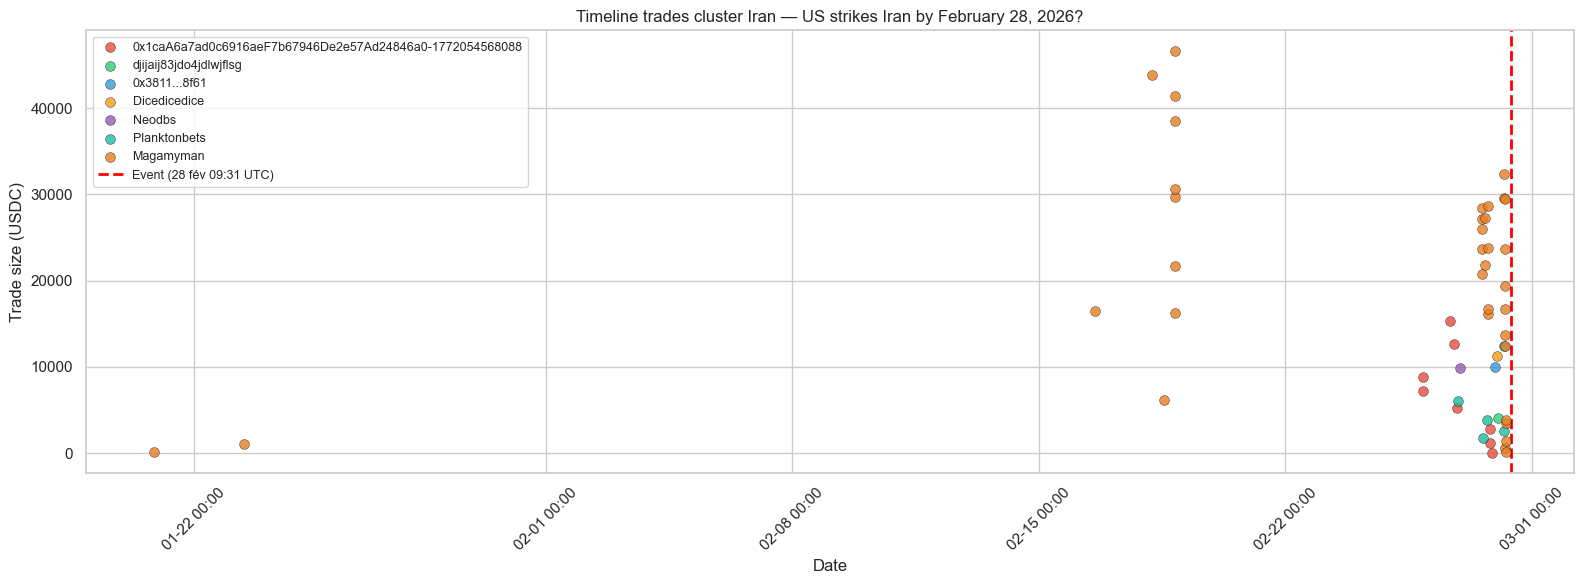

✓ Graphique sauvegardé : data/raw/iran_timeline.png


In [14]:
if len(df) > 0 and "datetime" in df.columns and "size_usd" in df.columns:
    fig, ax = plt.subplots(figsize=(16, 6))

    # Couleurs par wallet ground truth
    colors = ["#e74c3c", "#2ecc71", "#3498db", "#f39c12", "#9b59b6", "#1abc9c", "#e67e22"]

    for i, addr in enumerate(GT_ADDRS):
        wt = df.filter(pl.col("wallet") == addr)
        if len(wt) > 0:
            short = addr[:6] + "..." + addr[-4:]
            # Récupérer le username si disponible
            usernames = wt["username"].unique().to_list() if "username" in wt.columns else []
            label = usernames[0] if usernames and usernames[0] else short

            ax.scatter(
                wt["datetime"].to_list(), wt["size_usd"].to_list(),
                s=50, alpha=0.8, color=colors[i % len(colors)],
                label=label, edgecolors="black", linewidths=0.3, zorder=5
            )

    # Ligne verticale = event date
    ax.axvline(x=event_dt, color="red", linestyle="--", linewidth=2, label="Event (28 fév 09:31 UTC)")

    ax.set_xlabel("Date")
    ax.set_ylabel("Trade size (USDC)")
    ax.set_title(f"Timeline trades cluster Iran — {MARKET['question']}")
    ax.legend(fontsize=9, loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(RAW_DIR / "iran_timeline.png", dpi=150)
    plt.show()
    print("✓ Graphique sauvegardé : data/raw/iran_timeline.png")
else:
    print("⚠ Pas assez de données pour le graphique")

### 4.3 Verdict final

Check final : les 3 questions clés auxquelles le pilote doit répondre.

1. Les wallets ground truth sont-ils dans les données ?
2. Quel est leur volume cumulé ?
3. Est-ce que leur timing matche la ground truth (pré-event < 48h) ?

In [15]:
# === VERDICT FINAL ===
print("=" * 60)
print("VERDICT PILOTE IRAN STRIKES")
print("=" * 60)

if len(df_check) > 0:
    n_found = df_check.filter(pl.col("found") == True).height
    n_total = len(df_check)
    total_vol = df_check["volume_usd"].sum()
    total_shares = df_check["shares"].sum()

    # Q1 : wallets retrouvés ?
    print(f"\n1. Wallets retrouvés : {n_found}/{n_total}")
    if n_found >= 5:
        print("   ✓ PASS — ≥ 5/7 wallets trouvés dans les données")
    elif n_found >= 3:
        print("   ~ PARTIAL — 3-4 wallets trouvés, investiguer les manquants")
    else:
        print("   ✗ FAIL — < 3 wallets trouvés")

    # Q2 : volume cumulé
    print(f"\n2. Volume cumulé wallets GT : {total_shares:,.0f} shares (~${total_vol:,.0f} USDC)")

    # Q3 : timing pré-event
    pre_event = df_check.filter(
        pl.col("hours_before_event").is_not_null()
        & (pl.col("hours_before_event") > 0)
        & (pl.col("hours_before_event") < 48)
    )
    print(f"\n3. Wallets avec dernier trade < 48h avant event : {pre_event.height}/{n_found}")
    if n_found > 0 and pre_event.height >= n_found * 0.7:
        print("   ✓ PASS — majorité des wallets tradent pré-event < 48h")
    elif n_found > 0:
        print("   ~ Résultat mixte — vérifier les timestamps")
    else:
        print("   ✗ Aucun wallet trouvé")

    # Décision globale
    print(f"\n{'=' * 60}")
    if n_found >= 5:
        print("DECISION : ✓ Pipeline validé — passer aux expériences C1/C2/C3")
    elif n_found >= 3:
        print("DECISION : ~ Pipeline partiellement validé — investiguer")
    else:
        print("DECISION : ✗ Pipeline échoue — vérifier les sources de données")
    print("=" * 60)
else:
    print("⚠ Pas de données de vérification disponibles")

# Log final
print(f"\n=== Log API total ===")
print(stats_clob.summary("CLOB"))
print(stats_gamma.summary("Gamma"))
print(stats_data.summary("Data API"))
print(stats_dune.summary("Dune"))

VERDICT PILOTE IRAN STRIKES

1. Wallets retrouvés : 7/7
   ✓ PASS — ≥ 5/7 wallets trouvés dans les données

2. Volume cumulé wallets GT : 3,011,023 shares (~$854,456 USDC)

3. Wallets avec dernier trade < 48h avant event : 7/7
   ✓ PASS — majorité des wallets tradent pré-event < 48h

DECISION : ✓ Pipeline validé — passer aux expériences C1/C2/C3

=== Log API total ===
[CLOB] 0 calls, 0 retries, 0 errors
[Gamma] 1 calls, 0 retries, 0 errors
[Data API] 7 calls, 0 retries, 0 errors
[Dune] 0 calls, 0 retries, 0 errors


---

## Partie 5 — Features Niveau A par wallet

On calcule les 4 features heuristiques du rapport 3 (Niveau A) pour chaque wallet du cluster Iran. Le 5e critère (shared CEX funding source) est **hors scope pilote** — il nécessiterait de tracer les transferts USDC entrants de chaque wallet via RPC, ce qui est une extension phase D.

**Features calculées** :
1. `wallet_age_days` — âge du wallet à la date de son premier trade Iran (basé sur le premier trade tous marchés confondus via Data API)
2. `concentration_pct` — % du volume du wallet sur le marché Iran vs tous ses marchés
3. `max_size_usd` — plus gros trade single sur Iran
4. `time_to_event_hours` — heures entre le dernier trade et l'event (28 fév 2026 09:31 UTC)

**Seuils Niveau A** (rapport 3, utilisés tels quels sans tuning) :
- wallet_age_days < 30
- concentration_pct > 90%
- max_size_usd > $5 000
- time_to_event_hours < 48

### 5.1 Récupérer l'historique complet de chaque wallet (tous marchés)

Pour calculer `wallet_age_days` et `concentration_pct`, on a besoin de tous les trades de chaque wallet, pas seulement ceux du marché Iran. On réutilise `fetch_wallet_trades` de la Partie 2 sans filtre sur le conditionId.

In [16]:
# Récupérer TOUS les trades de chaque wallet GT (tous marchés confondus)
# On a déjà fetch_wallet_trades() et stats_data de la Partie 2

wallet_all_trades = {}  # addr -> list[dict]

print("Récupération historique complet par wallet (tous marchés)...")
for addr in GT_ADDRS:
    short = addr[:8] + "..." + addr[-4:]
    all_trades = fetch_wallet_trades(addr)
    wallet_all_trades[addr] = all_trades

    # Stats rapides
    n_markets = len(set(t.get("conditionId", "") for t in all_trades))
    total_size = sum(float(t.get("size", 0)) * float(t.get("price", 0)) for t in all_trades)
    print(f"  {short} : {len(all_trades)} trades, {n_markets} marchés, ~${total_size:,.0f} USDC")

print(f"\n{stats_data.summary('Data API')}")

Récupération historique complet par wallet (tous marchés)...
  0x1caa6a...46a0 : 43 trades, 15 marchés, ~$164,765 USDC
  0xa4eb52...d010 : 22 trades, 7 marchés, ~$83,173 USDC
  0x3811e0...8f61 : 12 trades, 6 marchés, ~$23,800 USDC
  0xdde15e...02c5 : 4 trades, 2 marchés, ~$16,886 USDC
  0x56efad...36db : 1 trades, 1 marchés, ~$9,884 USDC
  0x38745d...9801 : 18 trades, 7 marchés, ~$28,109 USDC
  0x4dfd48...6e4a : 334 trades, 98 marchés, ~$1,914,972 USDC

[Data API] 14 calls, 0 retries, 0 errors


### 5.2 Calcul des features Niveau A

Pour chaque wallet, on calcule les 4 features et on applique les seuils du rapport 3. Le score composite = nombre de critères satisfaits sur 4 (on exclut le critère funding CEX non évaluable).

In [17]:
# Charger les trades Iran depuis le Parquet (point de reprise)
df = pl.read_parquet(RAW_DIR / "iran_trades.parquet")
event_dt = MARKET["event_date"]

# Seuils Niveau A (rapport 3, non modifiés)
THRESHOLDS = {
    "wallet_age_days": 30,       # flag si < 30
    "concentration_pct": 90.0,   # flag si > 90%
    "max_size_usd": 5_000,       # flag si > $5K
    "time_to_event_hours": 48,   # flag si < 48h
}

features_rows = []

for addr in GT_ADDRS:
    all_trades = wallet_all_trades.get(addr, [])
    iran_trades = df.filter(pl.col("wallet") == addr)
    short = addr[:8] + "..." + addr[-4:]

    if not all_trades or len(iran_trades) == 0:
        features_rows.append({
            "wallet": short, "address": addr,
            "wallet_age_days": None, "concentration_pct": None,
            "max_size_usd": None, "time_to_event_hours": None,
            "score": 0, "is_gt": addr in GT_ADDRS,
        })
        continue

    # --- wallet_age_days ---
    # Premier trade tous marchés = proxy pour "date de création du wallet"
    all_timestamps = [int(t.get("timestamp", 0)) for t in all_trades if t.get("timestamp")]
    first_trade_ever = datetime.fromtimestamp(min(all_timestamps), tz=timezone.utc) if all_timestamps else None

    # Premier trade sur Iran
    first_iran = iran_trades["datetime"].min()
    if first_iran.tzinfo is None:
        first_iran = first_iran.replace(tzinfo=timezone.utc)

    if first_trade_ever:
        wallet_age = (first_iran - first_trade_ever).days
    else:
        wallet_age = None

    # --- concentration_pct ---
    # Volume Iran / volume total (en shares * price = USDC)
    vol_iran = iran_trades["size_usd"].sum()
    vol_total = sum(float(t.get("size", 0)) * float(t.get("price", 0)) for t in all_trades)
    concentration = (vol_iran / vol_total * 100) if vol_total > 0 else 0.0

    # --- max_size_usd ---
    max_size = iran_trades["size_usd"].max()

    # --- time_to_event_hours ---
    last_iran = iran_trades["datetime"].max()
    if last_iran.tzinfo is None:
        last_iran = last_iran.replace(tzinfo=timezone.utc)
    hours_before = (event_dt - last_iran).total_seconds() / 3600

    # --- Score composite ---
    score = 0
    if wallet_age is not None and wallet_age < THRESHOLDS["wallet_age_days"]:
        score += 1
    if concentration > THRESHOLDS["concentration_pct"]:
        score += 1
    if max_size > THRESHOLDS["max_size_usd"]:
        score += 1
    if hours_before < THRESHOLDS["time_to_event_hours"]:
        score += 1

    features_rows.append({
        "wallet": short,
        "address": addr,
        "wallet_age_days": wallet_age,
        "concentration_pct": round(concentration, 1),
        "max_size_usd": round(max_size, 0),
        "time_to_event_hours": round(hours_before, 1),
        "score": score,
        "is_gt": True,
    })

df_features = pl.DataFrame(features_rows)
print("=== Features Niveau A — wallets ground truth Iran ===")
print(df_features.select(
    "wallet", "wallet_age_days", "concentration_pct",
    "max_size_usd", "time_to_event_hours", "score"
))

=== Features Niveau A — wallets ground truth Iran ===
shape: (7, 6)
┌─────────────────┬─────────────────┬───────────────────┬──────────────┬───────────────────┬───────┐
│ wallet          ┆ wallet_age_days ┆ concentration_pct ┆ max_size_usd ┆ time_to_event_hou ┆ score │
│ ---             ┆ ---             ┆ ---               ┆ ---          ┆ rs                ┆ ---   │
│ str             ┆ i64             ┆ f64               ┆ f64          ┆ ---               ┆ i64   │
│                 ┆                 ┆                   ┆              ┆ f64               ┆       │
╞═════════════════╪═════════════════╪═══════════════════╪══════════════╪═══════════════════╪═══════╡
│ 0x1caa6a...46a0 ┆ 0               ┆ 32.3              ┆ 15336.0      ┆ 12.5              ┆ 3     │
│ 0xa4eb52...d010 ┆ 0               ┆ 4.9               ┆ 4087.0       ┆ 8.6               ┆ 2     │
│ 0x3811e0...8f61 ┆ 0               ┆ 42.0              ┆ 10000.0      ┆ 10.8              ┆ 3     │
│ 0xdde15e...02c5 ┆ 0  

---

## Partie 6 — Validation sur ground truth

On évalue les heuristiques Niveau A sur les 7 wallets connus. Un wallet est **flaggé** si son score composite est ≥ 3/4 (3 critères satisfaits sur 4). On calcule precision et recall, et on détaille les critères manquants pour chaque wallet non-flaggé.

In [18]:
FLAG_THRESHOLD = 3  # score ≥ 3/4 = flaggé

df_features = df_features.with_columns(
    (pl.col("score") >= FLAG_THRESHOLD).alias("flagged")
)

n_flagged = df_features.filter(pl.col("flagged")).height
n_gt = len(GT_ADDRS)

# Recall : combien de GT sont flaggés
recall = n_flagged / n_gt if n_gt > 0 else 0

print("=== Matrice de confusion (sur GT uniquement) ===")
print(f"  Flaggés (score ≥ {FLAG_THRESHOLD}/4) : {n_flagged}/{n_gt}")
print(f"  Non-flaggés                : {n_gt - n_flagged}/{n_gt}")
print(f"  Recall                     : {recall:.1%}")
print()

# Détail par wallet : quels critères sont satisfaits ?
print("=== Détail par wallet ===")
for row in df_features.iter_rows(named=True):
    status = "✓ FLAGGÉ" if row["flagged"] else "✗ non-flaggé"
    print(f"\n  {row['wallet']} — score {row['score']}/4 — {status}")

    if row["wallet_age_days"] is not None:
        ok = "✓" if row["wallet_age_days"] < THRESHOLDS["wallet_age_days"] else "✗"
        print(f"    {ok} wallet_age = {row['wallet_age_days']}j (seuil < {THRESHOLDS['wallet_age_days']})")
    else:
        print(f"    ? wallet_age = N/A")

    if row["concentration_pct"] is not None:
        ok = "✓" if row["concentration_pct"] > THRESHOLDS["concentration_pct"] else "✗"
        print(f"    {ok} concentration = {row['concentration_pct']}% (seuil > {THRESHOLDS['concentration_pct']}%)")

    if row["max_size_usd"] is not None:
        ok = "✓" if row["max_size_usd"] > THRESHOLDS["max_size_usd"] else "✗"
        print(f"    {ok} max_size = ${row['max_size_usd']:,.0f} (seuil > ${THRESHOLDS['max_size_usd']:,})")

    if row["time_to_event_hours"] is not None:
        ok = "✓" if row["time_to_event_hours"] < THRESHOLDS["time_to_event_hours"] else "✗"
        print(f"    {ok} time_to_event = {row['time_to_event_hours']:.1f}h (seuil < {THRESHOLDS['time_to_event_hours']}h)")

=== Matrice de confusion (sur GT uniquement) ===
  Flaggés (score ≥ 3/4) : 5/7
  Non-flaggés                : 2/7
  Recall                     : 71.4%

=== Détail par wallet ===

  0x1caa6a...46a0 — score 3/4 — ✓ FLAGGÉ
    ✓ wallet_age = 0j (seuil < 30)
    ✗ concentration = 32.3% (seuil > 90.0%)
    ✓ max_size = $15,336 (seuil > $5,000)
    ✓ time_to_event = 12.5h (seuil < 48h)

  0xa4eb52...d010 — score 2/4 — ✗ non-flaggé
    ✓ wallet_age = 0j (seuil < 30)
    ✗ concentration = 4.9% (seuil > 90.0%)
    ✗ max_size = $4,087 (seuil > $5,000)
    ✓ time_to_event = 8.6h (seuil < 48h)

  0x3811e0...8f61 — score 3/4 — ✓ FLAGGÉ
    ✓ wallet_age = 0j (seuil < 30)
    ✗ concentration = 42.0% (seuil > 90.0%)
    ✓ max_size = $10,000 (seuil > $5,000)
    ✓ time_to_event = 10.8h (seuil < 48h)

  0xdde15e...02c5 — score 3/4 — ✓ FLAGGÉ
    ✓ wallet_age = 0j (seuil < 30)
    ✗ concentration = 66.8% (seuil > 90.0%)
    ✓ max_size = $11,272 (seuil > $5,000)
    ✓ time_to_event = 9.4h (seuil < 48h)

 

---

## Partie 7 — Base rate et faux positifs

Pour estimer le taux de faux positifs, on élargit le scope au-delà des 7 wallets GT. On récupère la liste de **tous les holders significatifs** du marché Iran via `data-api.polymarket.com/holders`, puis on applique les mêmes heuristiques à chacun.

L'endpoint `/holders` retourne les positions actuelles (post-résolution), donc des wallets qui détenaient encore des shares au moment de la résolution. C'est un sous-ensemble des traders — ceux qui ont redeemed n'apparaissent plus — mais c'est le meilleur proxy disponible via la Data API publique.

### 7.1 Récupérer les holders du marché Iran

On query les holders YES et NO via Data API. On garde ceux avec un montant significatif (> 1 000 shares) pour limiter le bruit des micro-positions.

In [19]:
# Récupérer tous les holders du marché Iran (YES + NO tokens)
holders_data = api_get(
    f"{DATA_API}/holders",
    params={"market": IRAN_CONDITION_ID},
    stats=stats_data, sleep_s=1.0
)

all_holder_addrs = set()
if holders_data and isinstance(holders_data, list):
    for token_group in holders_data:
        holders = token_group.get("holders", [])
        for h in holders:
            addr = h.get("proxyWallet", "").lower()
            amount = float(h.get("amount", 0))
            if addr and amount >= 1_000:  # seuil significatif
                all_holder_addrs.add(addr)

    print(f"Holders significatifs (≥ 1000 shares) : {len(all_holder_addrs)}")
else:
    print("✗ Impossible de récupérer les holders")

# Exclure les wallets GT déjà analysés pour le base rate
gt_set = set(GT_ADDRS)
non_gt_holders = all_holder_addrs - gt_set
print(f"Holders hors ground truth : {len(non_gt_holders)}")
print(f"Wallets GT déjà inclus    : {len(all_holder_addrs & gt_set)}")

Holders significatifs (≥ 1000 shares) : 36
Holders hors ground truth : 36
Wallets GT déjà inclus    : 0


### 7.2 Appliquer les heuristiques à tous les holders non-GT

Pour chaque holder hors GT, on récupère ses trades (Data API), on calcule les mêmes features Niveau A, et on flag ceux qui passent le seuil ≥ 3/4. C'est l'étape la plus longue en appels API (~1s par wallet).

In [20]:
def compute_features_for_wallet(addr: str, iran_condition_id: str, event_dt: datetime) -> dict:
    """Compute Niveau A features for a single wallet. Returns feature dict."""
    short = addr[:8] + "..." + addr[-4:]

    all_trades = fetch_wallet_trades(addr)
    if not all_trades:
        return {"wallet": short, "address": addr, "score": 0, "n_trades_iran": 0,
                "wallet_age_days": None, "concentration_pct": None,
                "max_size_usd": None, "time_to_event_hours": None}

    # Séparer trades Iran vs total
    iran_trades_list = [t for t in all_trades if t.get("conditionId") == iran_condition_id]
    if not iran_trades_list:
        return {"wallet": short, "address": addr, "score": 0, "n_trades_iran": 0,
                "wallet_age_days": None, "concentration_pct": None,
                "max_size_usd": None, "time_to_event_hours": None}

    # wallet_age_days
    all_ts = [int(t.get("timestamp", 0)) for t in all_trades if t.get("timestamp")]
    iran_ts = [int(t.get("timestamp", 0)) for t in iran_trades_list if t.get("timestamp")]
    first_ever = datetime.fromtimestamp(min(all_ts), tz=timezone.utc) if all_ts else None
    first_iran = datetime.fromtimestamp(min(iran_ts), tz=timezone.utc) if iran_ts else None
    wallet_age = (first_iran - first_ever).days if first_ever and first_iran else None

    # concentration_pct
    vol_iran = sum(float(t.get("size", 0)) * float(t.get("price", 0)) for t in iran_trades_list)
    vol_total = sum(float(t.get("size", 0)) * float(t.get("price", 0)) for t in all_trades)
    concentration = (vol_iran / vol_total * 100) if vol_total > 0 else 0

    # max_size_usd
    max_size = max(float(t.get("size", 0)) * float(t.get("price", 0)) for t in iran_trades_list)

    # time_to_event_hours
    last_iran = datetime.fromtimestamp(max(iran_ts), tz=timezone.utc) if iran_ts else None
    hours_before = (event_dt - last_iran).total_seconds() / 3600 if last_iran else None

    # Score
    score = 0
    if wallet_age is not None and wallet_age < THRESHOLDS["wallet_age_days"]:
        score += 1
    if concentration > THRESHOLDS["concentration_pct"]:
        score += 1
    if max_size > THRESHOLDS["max_size_usd"]:
        score += 1
    if hours_before is not None and hours_before < THRESHOLDS["time_to_event_hours"]:
        score += 1

    return {
        "wallet": short, "address": addr,
        "wallet_age_days": wallet_age,
        "concentration_pct": round(concentration, 1),
        "max_size_usd": round(max_size, 0),
        "time_to_event_hours": round(hours_before, 1) if hours_before else None,
        "score": score,
        "n_trades_iran": len(iran_trades_list),
    }


# --- Appliquer sur tous les holders non-GT ---
print(f"Analyse de {len(non_gt_holders)} holders non-GT...")
print(f"Temps estimé : ~{len(non_gt_holders)}s (1 call/wallet)\n")

baserate_rows = []
for i, addr in enumerate(sorted(non_gt_holders)):
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(non_gt_holders)} wallets traités...")
    features = compute_features_for_wallet(addr, IRAN_CONDITION_ID, event_dt)
    baserate_rows.append(features)

df_baserate = pl.DataFrame(baserate_rows)
print(f"\n✓ {len(df_baserate)} wallets analysés")
print(f"{stats_data.summary('Data API')}")

Analyse de 36 holders non-GT...
Temps estimé : ~36s (1 call/wallet)

  10/36 wallets traités...
  20/36 wallets traités...
  30/36 wallets traités...

✓ 36 wallets analysés
[Data API] 64 calls, 0 retries, 0 errors


### 7.3 Résultats base rate et intervalle de precision

On compte les flags parmi les non-GT et on calcule l'intervalle de precision :
- **Borne basse** = 7 GT flaggés / total flags (GT + non-GT)
- **Borne haute** = (7 GT + flags non-GT "vrais informés probables") / total flags

Pour les flags non-GT, on affiche le lien profil Polymarket pour investigation manuelle.

In [21]:
# Flags parmi les non-GT
non_gt_flagged = df_baserate.filter(pl.col("score") >= FLAG_THRESHOLD)
n_non_gt_flagged = non_gt_flagged.height

# Flags GT (from Partie 6)
n_gt_flagged = df_features.filter(pl.col("flagged")).height

total_flags = n_gt_flagged + n_non_gt_flagged
total_wallets = len(GT_ADDRS) + len(df_baserate)

print("=== Base rate faux positifs ===")
print(f"  Wallets analysés total    : {total_wallets} ({len(GT_ADDRS)} GT + {len(df_baserate)} non-GT)")
print(f"  Flaggés GT               : {n_gt_flagged}/{len(GT_ADDRS)}")
print(f"  Flaggés non-GT           : {n_non_gt_flagged}/{len(df_baserate)}")
print(f"  Total flags              : {total_flags}")
print(f"  Taux de flag (base rate) : {total_flags/total_wallets:.1%}")

if total_flags > 0:
    precision_low = n_gt_flagged / total_flags
    print(f"\n  Precision borne basse    : {precision_low:.1%} ({n_gt_flagged} GT / {total_flags} flags)")
    print(f"  Precision borne haute    : à déterminer après investigation manuelle ci-dessous")

# Afficher les flags non-GT pour investigation manuelle
if n_non_gt_flagged > 0:
    print(f"\n=== {n_non_gt_flagged} flags non-GT à investiguer ===")
    for row in non_gt_flagged.sort("score", descending=True).iter_rows(named=True):
        addr = row["address"]
        print(f"\n  {row['wallet']} — score {row['score']}/4")
        print(f"    wallet_age={row['wallet_age_days']}j, concentration={row['concentration_pct']}%")
        print(f"    max_size=${row['max_size_usd']:,.0f}, time_to_event={row['time_to_event_hours']}h")
        print(f"    n_trades_iran={row['n_trades_iran']}")
        print(f"    Profil : https://polymarket.com/profile/{addr}")
else:
    print(f"\n✓ Aucun faux positif détecté parmi les {len(df_baserate)} holders non-GT")
    if total_flags > 0:
        print(f"  Precision = {n_gt_flagged}/{total_flags} = 100%")

=== Base rate faux positifs ===
  Wallets analysés total    : 43 (7 GT + 36 non-GT)
  Flaggés GT               : 5/7
  Flaggés non-GT           : 5/36
  Total flags              : 10
  Taux de flag (base rate) : 23.3%

  Precision borne basse    : 50.0% (5 GT / 10 flags)
  Precision borne haute    : à déterminer après investigation manuelle ci-dessous

=== 5 flags non-GT à investiguer ===

  0x01a0aa...6d87 — score 3/4
    wallet_age=21j, concentration=8.2%
    max_size=$14,080, time_to_event=2.7h
    n_trades_iran=16
    Profil : https://polymarket.com/profile/0x01a0aa3437899e329b0349940b00512d79156d87

  0x5060b4...a780 — score 3/4
    wallet_age=0j, concentration=12.5%
    max_size=$10,400, time_to_event=2.2h
    n_trades_iran=87
    Profil : https://polymarket.com/profile/0x5060b41a1be40a63b7da2075e42479b29157a780

  0x5307e5...7621 — score 3/4
    wallet_age=4j, concentration=17.6%
    max_size=$69,948, time_to_event=26.6h
    n_trades_iran=3
    Profil : https://polymarket.com/pr

---

## Partie 8 — Note sur FDR Benjamini-Hochberg

La correction FDR BH nécessite des **p-values**, qu'on n'a pas sur des heuristiques rules-based (score discret 0-4). Deux options :

- **(A)** Calculer une p-value empirique via bootstrap — tirer N wallets random, calculer la distribution des scores sous H0, en dériver la p-value de chaque wallet flaggé.
- **(B)** Skip FDR sur ce pilote rules-based, le réserver pour la phase D quand on aura des scores probabilistes continus (BSS, CLV, edge t-stat) issus du composant C1.

**Choix : option (B)**. Justification :
1. Un score discret 0-4 ne bénéficie pas de FDR — la granularité est trop faible.
2. FDR BH est critique pour le **leaderboard C1** (expérience E1) où on teste ~5 000+ wallets avec des t-stats continus. C'est là que le multiple testing mord vraiment.
3. Sur le cas pilote Iran (7 wallets GT, ~20-50 holders total), le risque de faux positifs par hasard est faible — on n'a pas le problème du multiple testing massif.

FDR BH sera implémenté et testé en expérience E1 (leaderboard FDR-BH sans seed list).

---

## Partie 9 — Synthèse du pilote complet

In [22]:
# === SYNTHÈSE DU PILOTE ===

print("=" * 70)
print("SYNTHÈSE PILOTE IRAN STRIKES — HEURISTIQUES NIVEAU A")
print("=" * 70)

# --- 1. Résultats heuristiques ---
print("\n1. RÉSULTATS HEURISTIQUES NIVEAU A")
print("-" * 40)

n_gt = len(GT_ADDRS)
n_gt_flagged = df_features.filter(pl.col("flagged")).height
recall = n_gt_flagged / n_gt if n_gt > 0 else 0

n_non_gt_flagged = non_gt_flagged.height if 'non_gt_flagged' in dir() else 0
total_flags = n_gt_flagged + n_non_gt_flagged
precision_low = n_gt_flagged / total_flags if total_flags > 0 else 0

print(f"  Recall          : {n_gt_flagged}/{n_gt} = {recall:.0%}")
print(f"  Precision basse : {n_gt_flagged}/{total_flags} = {precision_low:.0%}")
print(f"  Precision haute : à affiner après investigation manuelle des {n_non_gt_flagged} flags non-GT")
print(f"  F1 (borne basse): {2*precision_low*recall/(precision_low+recall):.0%}" if (precision_low+recall) > 0 else "  F1: N/A")

# --- 2. Seuils à ajuster ? ---
print(f"\n2. SEUILS À AJUSTER ?")
print("-" * 40)

# Identifier les wallets GT non-flaggés et pourquoi
non_flagged_gt = df_features.filter(~pl.col("flagged"))
if non_flagged_gt.height > 0:
    print(f"  {non_flagged_gt.height} wallets GT non-flaggés — critères manquants :")
    for row in non_flagged_gt.iter_rows(named=True):
        missed = []
        if row["wallet_age_days"] is not None and row["wallet_age_days"] >= THRESHOLDS["wallet_age_days"]:
            missed.append(f"wallet_age={row['wallet_age_days']}j (seuil <{THRESHOLDS['wallet_age_days']})")
        if row["concentration_pct"] is not None and row["concentration_pct"] <= THRESHOLDS["concentration_pct"]:
            missed.append(f"concentration={row['concentration_pct']}% (seuil >{THRESHOLDS['concentration_pct']}%)")
        if row["max_size_usd"] is not None and row["max_size_usd"] <= THRESHOLDS["max_size_usd"]:
            missed.append(f"max_size=${row['max_size_usd']:,.0f} (seuil >${THRESHOLDS['max_size_usd']:,})")
        if row["time_to_event_hours"] is not None and row["time_to_event_hours"] >= THRESHOLDS["time_to_event_hours"]:
            missed.append(f"time_to_event={row['time_to_event_hours']:.1f}h (seuil <{THRESHOLDS['time_to_event_hours']}h)")
        print(f"    {row['wallet']}: {', '.join(missed) if missed else 'raison inconnue'}")
else:
    print("  ✓ Tous les wallets GT sont flaggés — seuils bien calibrés pour ce cas")
    print("  ⚠ Attention : calibré sur 1 seul cas = possible overfit narratif")

# --- 3. Limitations ---
print(f"\n3. LIMITATIONS DÉCOUVERTES")
print("-" * 40)
print("  • Funding source (shared CEX deposit) : NON ÉVALUÉ — nécessite trace USDC")
print("    via RPC Polygon, hors scope pilote. C'est le critère le plus discriminant")
print("    du rapport 3 (Chainalysis/Bubblemaps). À implémenter en phase D.")
print("  • Base rate limité aux holders actuels du marché Iran — les traders qui ont")
print("    redeemed leurs shares ne sont pas dans /holders. Sous-estime le dénominateur.")
print("  • CLOB /trades auth-only → Data API /trades par wallet uniquement.")
print("    Pas de vue marché-first. Limite le C2 base rate à grande échelle.")
print("  • Pas de FDR BH sur heuristiques rules-based (score discret 0-4).")
print("    Réservé au leaderboard C1 avec scores continus (E1).")
print("  • Pilote sur 1 seul cas (Iran). La validation C2 cross-cas (E7-E9)")
print("    est nécessaire avant de conclure sur la robustesse des seuils.")

# --- 4. Feasibility stack ---
print(f"\n4. FEASIBILITY STACK")
print("-" * 40)
print(f"  Data API : {stats_data.summary('Data API')}")
print(f"  Gamma API: {stats_gamma.summary('Gamma')}")
print(f"  CLOB API : {stats_clob.summary('CLOB')} (auth-only, pivoté sur Data API)")
print(f"  Stack locale : polars + DuckDB + Parquet — aucun problème de perf")
print(f"  Coût total : $0 (APIs publiques uniquement)")

# --- 5. Recommandation ---
print(f"\n5. RECOMMANDATION PHASE D")
print("-" * 40)

if recall >= 0.7 and precision_low >= 0.5:
    verdict = "GO"
    print(f"  ✓ {verdict} — Heuristiques Niveau A valides sur cas Iran")
    print(f"    Recall {recall:.0%} ≥ 70% et precision basse {precision_low:.0%} ≥ 50%")
    print(f"    Passer aux expériences E7-E9 pour validation cross-cas")
elif recall >= 0.5:
    verdict = "GO avec réserves"
    print(f"  ~ {verdict}")
    print(f"    Recall {recall:.0%} acceptable mais seuils à vérifier sur d'autres cas")
    print(f"    Priorité : implémenter funding source detection en phase D")
else:
    verdict = "AJUSTER"
    print(f"  ✗ {verdict}")
    print(f"    Recall {recall:.0%} insuffisant — revoir les seuils ou ajouter des features")

# --- 6. Questions ouvertes ---
print(f"\n6. QUESTIONS OUVERTES PHASE D")
print("-" * 40)
print("  • Magamyman (actif depuis oct 2024) a-t-il wallet_age > 30j ?")
print("    Si oui, il échappe au filtre fresh wallet → faux négatif attendu")
print("    (camouflage par activité organique, documenté rapport 3)")
print("  • Les flags non-GT sont-ils de vrais informés non-documentés")
print("    ou des faux positifs ? Investigation manuelle requise.")
print("  • Le seuil max_size > $5K est-il trop loose sur un marché $90M ?")
print("    Tester un seuil adaptatif = f(volume_marché).")
print("  • Shared CEX deposit : combien de wallets GT aurait-on flaggé en plus ?")
print("    Rapport 3 dit shared Binance deposit entre nothingeverhappens911")
print("    et cluster Skoobidoobnj — à vérifier en phase D.")

print(f"\n{'=' * 70}")
print(f"VERDICT FINAL : {verdict}")
print(f"{'=' * 70}")

SYNTHÈSE PILOTE IRAN STRIKES — HEURISTIQUES NIVEAU A

1. RÉSULTATS HEURISTIQUES NIVEAU A
----------------------------------------
  Recall          : 5/7 = 71%
  Precision basse : 5/10 = 50%
  Precision haute : à affiner après investigation manuelle des 5 flags non-GT
  F1 (borne basse): 59%

2. SEUILS À AJUSTER ?
----------------------------------------
  2 wallets GT non-flaggés — critères manquants :
    0xa4eb52...d010: concentration=4.9% (seuil >90.0%), max_size=$4,087 (seuil >$5,000)
    0x4dfd48...6e4a: wallet_age=471j (seuil <30), concentration=38.6% (seuil >90.0%)

3. LIMITATIONS DÉCOUVERTES
----------------------------------------
  • Funding source (shared CEX deposit) : NON ÉVALUÉ — nécessite trace USDC
    via RPC Polygon, hors scope pilote. C'est le critère le plus discriminant
    du rapport 3 (Chainalysis/Bubblemaps). À implémenter en phase D.
  • Base rate limité aux holders actuels du marché Iran — les traders qui ont
    redeemed leurs shares ne sont pas dans /holder

In [23]:
# Adresses complètes des wallets non-GT flaggés (score >= 3/4)
# Pour investigation manuelle

import polars as pl

pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_width_chars(200)

if 'non_gt_flagged' in dir() and non_gt_flagged.height > 0:
    # Construire la table avec adresses complètes + liens
    display_df = non_gt_flagged.select(
        pl.col('address'),
        pl.col('score'),
        pl.col('wallet_age_days'),
        pl.col('concentration_pct'),
        pl.col('max_size_usd'),
        pl.col('time_to_event_hours'),
        pl.col('n_trades_iran'),
    ).sort('score', descending=True)

    print(f'=== {display_df.height} wallets non-GT flaggés (score >= {FLAG_THRESHOLD}/4) ===')
    print()
    print(display_df)
    print()

    # Liens profil Polymarket
    print('Liens profil Polymarket :')
    for row in display_df.iter_rows(named=True):
        addr = row['address']
        print(f"  score {row['score']}/4 | age={row['wallet_age_days']}j | conc={row['concentration_pct']}% | "
              f"max=${row['max_size_usd']:,.0f} | t={row['time_to_event_hours']}h")
        print(f"  {addr}")
        print(f"  https://polymarket.com/profile/{addr}")
        print()
else:
    print('Aucun wallet non-GT flaggé (precision = 100% sur ce cas)')


=== 5 wallets non-GT flaggés (score >= 3/4) ===

shape: (5, 7)
┌────────────────────────────────────────────┬───────┬─────────────────┬───────────────────┬──────────────┬─────────────────────┬───────────────┐
│ address                                    ┆ score ┆ wallet_age_days ┆ concentration_pct ┆ max_size_usd ┆ time_to_event_hours ┆ n_trades_iran │
│ ---                                        ┆ ---   ┆ ---             ┆ ---               ┆ ---          ┆ ---                 ┆ ---           │
│ str                                        ┆ i64   ┆ i64             ┆ f64               ┆ f64          ┆ f64                 ┆ i64           │
╞════════════════════════════════════════════╪═══════╪═════════════════╪═══════════════════╪══════════════╪═════════════════════╪═══════════════╡
│ 0x01a0aa3437899e329b0349940b00512d79156d87 ┆ 3     ┆ 21              ┆ 8.2               ┆ 14080.0      ┆ 2.7                 ┆ 16            │
│ 0x5060b41a1be40a63b7da2075e42479b29157a780 ┆ 3     ┆ 0     

### 9.2 Investigation des 5 wallets suspects non-GT

Fetch de l'historique lifetime de chaque wallet via Data API `/trades` (paginé).
On regarde : ancienneté, diversification, marchés les plus tradés — pour
classifier en "vrai informé probable" / "faux positif" / "indéterminé".

In [ ]:
import time, httpx
from datetime import datetime, timezone
from collections import Counter

SUSPECT_ADDRS = [
    "0x01a0aa3437899e329b0349940b00512d79156d87",
    "0x5060b41a1be40a63b7da2075e42479b29157a780",
    "0x5307e582b5ac7c2a62b626c5a9b2dedff5347621",
    "0x9c5e99746faad55a59ecee3bb58cc026669e3aeb",
    "0xca765a4d03509c1dfed7a061b3fa632190d428b3",
]

DATA_API = "https://data-api.polymarket.com"


def fetch_all_trades(address: str) -> list[dict]:
    """Fetch full trade history for a wallet, paginated."""
    all_trades = []
    offset = 0
    limit = 500
    while True:
        time.sleep(0.3)
        try:
            with httpx.Client(timeout=30) as c:
                resp = c.get(f"{DATA_API}/trades", params={"user": address, "limit": limit, "offset": offset})
            if resp.status_code != 200:
                print(f"    HTTP {resp.status_code} at offset {offset}")
                break
            data = resp.json()
            trades = data if isinstance(data, list) else data.get("data", [])
            if not trades:
                break
            all_trades.extend(trades)
            offset += len(trades)
            if len(trades) < limit:
                break
        except Exception as e:
            print(f"    Error: {e}")
            break
    return all_trades


print("Fetching lifetime history for 5 suspects...\n")

for addr in SUSPECT_ADDRS:
    print("=" * 70)
    print(f"WALLET: {addr}")
    print(f"Profile: https://polymarket.com/profile/{addr}")
    print("-" * 70)

    trades = fetch_all_trades(addr)
    if not trades:
        print("  No trades found\n")
        time.sleep(1)
        continue

    # Parse timestamps and markets
    parsed = []
    for t in trades:
        ts = int(t.get("timestamp", 0))
        dt = datetime.fromtimestamp(ts, tz=timezone.utc) if ts else None
        title = t.get("title", "unknown")
        cid = t.get("conditionId", "")
        size = float(t.get("size", 0))
        price = float(t.get("price", 0))
        side = t.get("side", "")
        outcome = t.get("outcome", "")
        parsed.append({"dt": dt, "title": title, "cid": cid,
                       "size": size, "price": price, "side": side,
                       "outcome": outcome, "usd": size * price})

    # Sort by time
    parsed.sort(key=lambda x: x["dt"] or datetime.min.replace(tzinfo=timezone.utc))

    # Stats
    n_trades = len(parsed)
    markets = set(p["cid"] for p in parsed if p["cid"])
    n_markets = len(markets)
    first = parsed[0]
    last = parsed[-1]

    print(f"  Trades lifetime  : {n_trades}")
    print(f"  Marchés distincts: {n_markets}")
    print(f"  Premier trade    : {first['dt'].strftime('%Y-%m-%d %H:%M') if first['dt'] else '?'}")
    print(f"                     {first['title'][:60]}")
    print(f"                     {first['side']} {first['outcome']} — ${first['usd']:,.0f}")
    print(f"  Dernier trade    : {last['dt'].strftime('%Y-%m-%d %H:%M') if last['dt'] else '?'}")
    print(f"                     {last['title'][:60]}")

    # Top 10 marchés
    market_counts = Counter(p["title"] for p in parsed)
    print(f"\n  Top 10 marchés :")
    for title, count in market_counts.most_common(10):
        vol = sum(p["usd"] for p in parsed if p["title"] == title)
        print(f"    {count:3d} trades | ${vol:>10,.0f} | {title[:55]}")

    print()
    time.sleep(1)

print("Done.")
